# Explainable Ensemble Machine Learning for Early Chronic Kidney Disease Prediction

**ML for Social Good Ensemble Challenge — Mission Health**
CIA-3, Machine Learning (MCA 521-4)

> This model is a screening support tool only, not a medical diagnostic system.

## Q1. Real-World Impact Framing

**Problem:** Chronic Kidney Disease (CKD) is often symptomless until it is advanced. Most published CKD datasets
predict from a full diagnostic lab panel (serum creatinine, albumin, urine tests) — but a patient who already has
those results basically already has the diagnosis. A more useful *screening* tool should flag risk from information
a resource-limited clinic can collect **without** an advanced renal lab panel: age, blood pressure, a glucometer
reading, and basic comorbidity history.

**Beneficiaries:** patients, rural/under-resourced clinics, primary healthcare workers, public health bodies.

**Prediction target:** binary classification — `CKD` vs `Not CKD`.

**Measurable impact:** more patients flagged for a confirmatory renal lab panel *before* symptoms appear, using
only cheap, widely available measurements.

**Why ML is suitable:** CKD risk depends on non-linear interactions between comorbidities (e.g. hypertension
*and* diabetes together carrying more risk than either alone) — a pattern well suited to ML, especially ensembles.

**Dataset source:** [UCI Chronic Kidney Disease Data Set](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease),
400 patients, 24 clinical/lab attributes, collected at a hospital in Tamil Nadu, India. We deliberately use only
a **subset** of its features (see Q2.5) — the ones obtainable without a lab-based renal panel.

**Unit of analysis:** one patient record (one row = one patient's clinical results at a single visit).

**Responsible-use limitations:** small, single-hospital dataset; not externally validated; must never replace a
clinician's diagnosis — output is only a screening flag for further testing.

## Q2. Data Wrangling and Feature Engineering

### 2.1 Load the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
RANDOM_STATE = 42

DATA_PATH = os.path.join("data", "chronic_kidney_disease_raw.csv")

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    from ucimlrepo import fetch_ucirepo
    ckd = fetch_ucirepo(id=336)
    df = pd.concat([ckd.data.features, ckd.data.targets], axis=1)
    os.makedirs("data", exist_ok=True)
    df.to_csv(DATA_PATH, index=False)

print(df.shape)
df.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


### 2.2 Data quality audit — missing values, duplicates, invalid text, dtypes

The raw data has missing values in nearly every column and some messy text entries (e.g. `'ckd\t'` instead of
`'ckd'`), typical of hand-entered clinical records.

In [2]:
df.isnull().sum().sort_values(ascending=False)

rbc      152
rbcc     131
wbcc     106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

In [3]:
# Strip stray whitespace/tabs found in the raw text columns FIRST, so that two rows which are
# identical except for messy text (e.g. 'ckd' vs 'ckd\t') are correctly recognised as duplicates below.
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "?": np.nan})

df["class"] = df["class"].replace({"ckd\t": "ckd"})
df["dm"] = df["dm"].replace({"\tno": "no", "\tyes": "yes"})
df["cad"] = df["cad"].replace({"\tno": "no"})

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["bp"] = pd.to_numeric(df["bp"], errors="coerce")
df["bgr"] = pd.to_numeric(df["bgr"], errors="coerce")

df["target"] = (df["class"] == "ckd").astype(int)
print(df["class"].unique())

<ArrowStringArray>
['ckd', 'notckd']
Length: 2, dtype: str


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 0


In [5]:
# Invalid/impossible value check on the three numeric features we actually model -> treat as missing
# rather than trust at face value (fixed clinical bounds, not statistics learned from the data).
invalid_counts = {}
invalid_counts["age"] = int(((df["age"] < 0) | (df["age"] > 110)).sum())
invalid_counts["bp"] = int((df["bp"] < 0).sum())
invalid_counts["bgr"] = int((df["bgr"] < 0).sum())

df.loc[(df["age"] < 0) | (df["age"] > 110), "age"] = np.nan
df.loc[df["bp"] < 0, "bp"] = np.nan
df.loc[df["bgr"] < 0, "bgr"] = np.nan

pd.Series(invalid_counts, name="invalid_values_found")

age    0
bp     0
bgr    0
Name: invalid_values_found, dtype: int64

No invalid values were found in this particular sample, but the guard is kept so the same cleaning code stays
correct if it is ever re-run on a fresh batch of patient data.

### 2.3 Exploratory Data Analysis

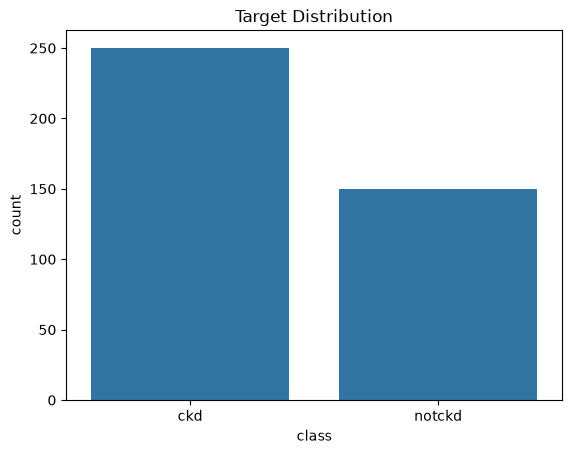

class
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64


In [6]:
sns.countplot(x="class", data=df, order=["ckd", "notckd"])
plt.title("Target Distribution")
plt.show()
print(df["class"].value_counts(normalize=True).round(3) * 100)

**Observation:** ~62% of patients are CKD-positive — a moderate imbalance, handled with SMOTE in Section 2.5.

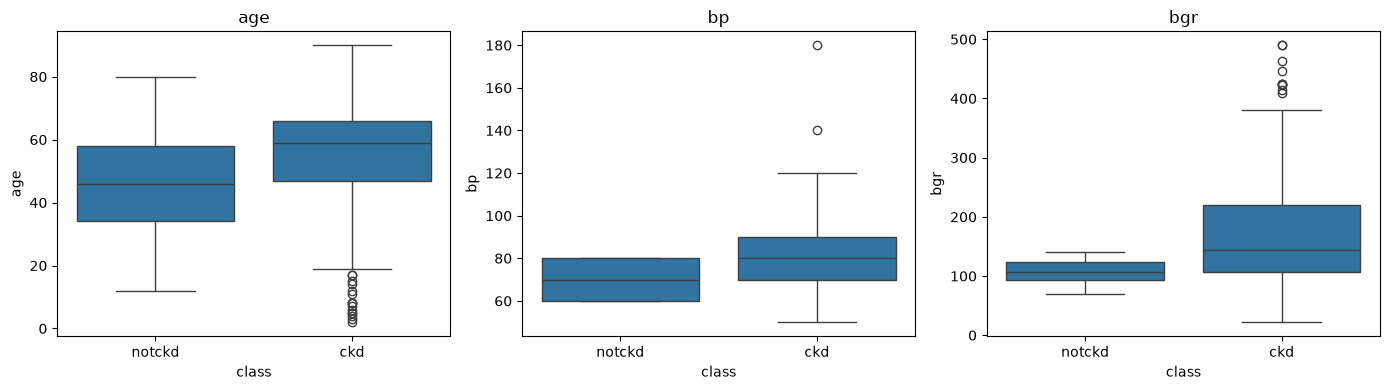

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["age", "bp", "bgr"]):
    sns.boxplot(x="class", y=col, data=df, order=["notckd", "ckd"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

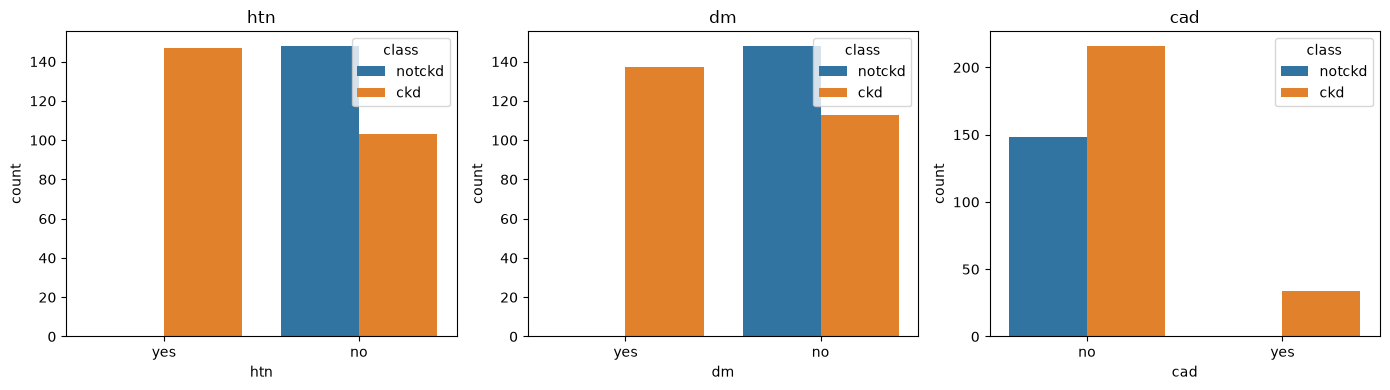

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["htn", "dm", "cad"]):
    sns.countplot(x=col, hue="class", data=df, hue_order=["notckd", "ckd"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** blood pressure and blood glucose are visibly higher in CKD patients, and hypertension/diabetes
`yes` responses are concentrated in the CKD group — consistent with these being the two leading real-world causes
of CKD. None of these differences look as extreme/clean-cut as the full diagnostic lab panel would (e.g. serum
creatinine), which is exactly why this restricted feature set gives a more realistic, harder prediction problem.

### 2.4 Outlier Analysis

In [9]:
outlier_counts = {}
for col in ["age", "bp", "bgr"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

pd.Series(outlier_counts, name="iqr_outlier_count")

age    10
bp     36
bgr    34
Name: iqr_outlier_count, dtype: int64

**Decision:** we keep these outliers rather than remove them. A very high blood-pressure or blood-glucose reading
is itself a genuine risk signal in exactly the at-risk patients this model needs to catch — deleting them would
remove real signal, not noise. Tree-based models (Random Forest, XGBoost) are naturally robust to this kind of
skew, and the `StandardScaler` step keeps the Logistic Regression baseline stable.

### 2.5 Feature selection — why we drop the diagnostic lab panel

The full UCI dataset also includes serum creatinine, specific gravity, albumin, hemoglobin and urine microscopy —
but these are not independent *risk factors*, they are the clinical lab panel used to **diagnose** CKD in the
first place (serum creatinine directly determines the diagnostic eGFR calculation). Training on them makes the
model reproduce the diagnosis rather than predict *early risk*. We can show this directly: a plain model trained
on the *full* diagnostic feature set below:

In [10]:
from sklearn.linear_model import LogisticRegression as _QuickLR
from sklearn.impute import SimpleImputer as _QuickImputer
from sklearn.preprocessing import StandardScaler as _QuickScaler, OneHotEncoder as _QuickOHE
from sklearn.compose import ColumnTransformer as _QuickCT
from sklearn.pipeline import Pipeline as _QuickPipe
from sklearn.model_selection import cross_val_score, StratifiedKFold as _QuickSKF

_full_numeric = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc", "sod", "pot", "hemo", "pcv", "wbcc", "rbcc"]
_full_categorical = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]
for c in _full_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

_quick_pre = _QuickCT([
    ("num", _QuickPipe([("imp", _QuickImputer(strategy="median")), ("sc", _QuickScaler())]), _full_numeric),
    ("cat", _QuickPipe([("imp", _QuickImputer(strategy="most_frequent")), ("oh", _QuickOHE(handle_unknown="ignore"))]), _full_categorical),
])
_quick_pipe = _QuickPipe([("pre", _quick_pre), ("clf", _QuickLR(max_iter=1000))])
_quick_auc = cross_val_score(_quick_pipe, df[_full_numeric + _full_categorical], df["target"],
                              cv=_QuickSKF(5, shuffle=True, random_state=RANDOM_STATE), scoring="roc_auc")
print(f"Full 24-feature set, plain Logistic Regression, 5-fold CV ROC-AUC: {_quick_auc.mean():.4f}")

Full 24-feature set, plain Logistic Regression, 5-fold CV ROC-AUC: 1.0000


...already reaches essentially perfect ROC-AUC with no ensembling and no tuning at all — confirming these lab
features leave the ensembles no real headroom to show an advantage, and that this is a property of the *features*,
not a bug in the modelling code. We therefore keep only the six features a resource-limited clinic can obtain
**without** ordering a renal lab panel:

In [11]:
risk_numeric = ["age", "bp", "bgr"]
risk_categorical = ["htn", "dm", "cad"]

# Single engineered feature: hypertension AND diabetes together are the two leading causes of CKD,
# so their co-occurrence is a stronger signal than either flag alone.
df["htn_dm_comorbidity"] = ((df["htn"] == "yes") & (df["dm"] == "yes")).astype(float)
df.loc[df["htn"].isna() | df["dm"].isna(), "htn_dm_comorbidity"] = np.nan

engineered_cols = ["htn_dm_comorbidity"]
df[risk_numeric + risk_categorical + engineered_cols + ["class"]].head()

,age,bp,bgr,htn,dm,cad,htn_dm_comorbidity,class
0,48.0,80.0,121.0,yes,yes,no,1.0,ckd
1,7.0,50.0,NaN,no,no,no,0.0,ckd
2,62.0,80.0,423.0,no,yes,no,0.0,ckd
3,48.0,70.0,117.0,yes,no,no,0.0,ckd
4,51.0,80.0,106.0,no,no,no,0.0,ckd


### 2.6 Train/Validation/Test split and preprocessing pipeline

70/15/15 stratified split. All imputation, scaling, encoding and SMOTE oversampling are learned **only on the
training data**, inside one scikit-learn/imblearn `Pipeline`, so nothing from validation/test leaks into training.
We use **median** imputation for numeric features (robust to the skew/outliers noted in Section 2.4, unlike mean)
and **most-frequent** imputation for categorical features (the standard default for nominal data).

In [12]:
from sklearn.model_selection import train_test_split

feature_cols = risk_numeric + risk_categorical + engineered_cols
X = df[feature_cols]
y = df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (280, 7)  Val: (60, 7)  Test: (60, 7)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

num_features = risk_numeric + engineered_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, risk_categorical),
])

def make_pipeline(model):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])

## Q3. Ensemble Architecture, Tuning, and Comparison

Baseline, then three ensembles: bagging (Random Forest), boosting (XGBoost), and a heterogeneous stacking model.
Every model trains on `X_train` only; `X_val` is used to sanity-check; `X_test` is touched exactly once, at the end.

### 3.1 Baseline — Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

def evaluate(pipeline, X, y):
    pred = pipeline.predict(X)
    proba = pipeline.predict_proba(X)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, proba),
    }
    return metrics, pred, proba

baseline = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
baseline.fit(X_train, y_train)
val_metrics, _, _ = evaluate(baseline, X_val, y_val)
pd.Series(val_metrics, name="Baseline (validation)").round(3)

Accuracy     0.867
Precision    1.000
Recall       0.789
F1           0.882
ROC-AUC      0.915
Name: Baseline (validation), dtype: float64

### 3.2 Bagging — Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
rf.fit(X_train, y_train)
val_metrics, _, _ = evaluate(rf, X_val, y_val)
pd.Series(val_metrics, name="Random Forest (validation)").round(3)

Accuracy     0.933
Precision    0.972
Recall       0.921
F1           0.946
ROC-AUC      0.947
Name: Random Forest (validation), dtype: float64

### 3.3 Boosting — XGBoost

In [16]:
from xgboost import XGBClassifier

xgb = make_pipeline(XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"))
xgb.fit(X_train, y_train)
val_metrics, _, _ = evaluate(xgb, X_val, y_val)
pd.Series(val_metrics, name="XGBoost (validation)").round(3)

Accuracy     0.917
Precision    0.971
Recall       0.895
F1           0.932
ROC-AUC      0.946
Name: XGBoost (validation), dtype: float64

### 3.4 Hyperparameter Tuning

`RandomizedSearchCV`, 5-fold stratified cross-validation, scored on ROC-AUC, fit on training data only.

In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_params = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": randint(2, 10),
}
rf_search = RandomizedSearchCV(make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
                                rf_params, n_iter=10, cv=cv, scoring="roc_auc",
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

Best RF params: {'model__max_depth': None, 'model__min_samples_split': 8, 'model__n_estimators': 221}


In [18]:
xgb_params = {
    "model__learning_rate": uniform(0.01, 0.29),
    "model__max_depth": randint(3, 8),
    "model__n_estimators": randint(100, 400),
}
xgb_search = RandomizedSearchCV(make_pipeline(XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
                                 xgb_params, n_iter=10, cv=cv, scoring="roc_auc",
                                 random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGBoost params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Best XGBoost params: {'model__learning_rate': np.float64(0.010225842093894155), 'model__max_depth': 6, 'model__n_estimators': 376}


### 3.5 Heterogeneous Stacking Model

Combines Logistic Regression, Random Forest and XGBoost as base learners, with a Logistic Regression meta-model.
`StackingClassifier` uses internal 5-fold cross-validation to build the meta-model's training data, so the
meta-model never sees a base learner's own predictions on rows it was trained on.

Two details matter here for a leakage-safe stacking model:

1. **We reuse the tuned Random Forest / XGBoost hyperparameters found above** (not fresh defaults), so this
   ensemble genuinely benefits from Section 3.4's tuning, not just the untuned models from 3.2/3.3.
2. **SMOTE is placed inside each base learner's own mini-pipeline**, not once before stacking. If SMOTE ran once
   on the whole training fold beforehand, a synthetic point and the real points it was interpolated from could end
   up on opposite sides of `StackingClassifier`'s internal CV split — a subtle information leak between the folds
   used to build the meta-model. Resampling separately inside each internal fold avoids that.

In [19]:
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone

tuned_rf_model = best_rf.named_steps["model"]
tuned_xgb_model = best_xgb.named_steps["model"]

def smote_wrapped(model):
    return ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", clone(model))])

base_learners = [
    ("lr", smote_wrapped(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))),
    ("rf", smote_wrapped(tuned_rf_model)),
    ("xgb", smote_wrapped(tuned_xgb_model)),
]
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
)
stacking = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking_model),
])
stacking.fit(X_train, y_train)
val_metrics, _, _ = evaluate(stacking, X_val, y_val)
pd.Series(val_metrics, name="Stacking (validation)").round(3)

Accuracy     0.950
Precision    1.000
Recall       0.921
F1           0.959
ROC-AUC      0.943
Name: Stacking (validation), dtype: float64

### 3.6 Final Comparison on the Untouched Test Set

**Note:** every "(validation)" table above (Sections 3.1-3.5) was measured on `X_val`, used only as a quick sanity
check while building each model. The table below is measured on `X_test` instead — a different 60 patients, seen
for the first time only here. Validation and test are each just 60 patients, so it is normal (not a bug) for the
same model's numbers to shift by several points between the two — e.g. the baseline's validation Accuracy above is
not the same figure as its test Accuracy below. Only the test-set numbers below count as the official comparison.

In [20]:
final_models = {
    "Baseline (Logistic Regression)": baseline,
    "Bagging (Random Forest, tuned)": best_rf,
    "Boosting (XGBoost, tuned)": best_xgb,
    "Stacking (LR+RF+XGB)": stacking,
}

results, preds, probas = {}, {}, {}
for name, model in final_models.items():
    m, p, pr = evaluate(model, X_test, y_test)
    results[name], preds[name], probas[name] = m, p, pr

comparison_table = pd.DataFrame(results).T.round(4)
comparison_table.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
"Boosting (XGBoost, tuned)",0.9167,0.9706,0.8919,0.9296,0.9853
"Bagging (Random Forest, tuned)",0.9333,0.9714,0.9189,0.9444,0.9835
Stacking (LR+RF+XGB),0.9333,0.9714,0.9189,0.9444,0.9835
Baseline (Logistic Regression),0.7833,1.0000,0.6486,0.7869,0.9177


**Why the baseline's Precision is a perfect 1.000:** this is not a leakage red flag like an all-metrics-saturated
model would be — it means that of the patients the baseline was confident enough to label "CKD", it never raised a
false alarm, but it also declined to flag a large share of true CKD cases (Recall 0.649), which is exactly the
weak spot the confusion matrix below shows and the one the ensembles fix.

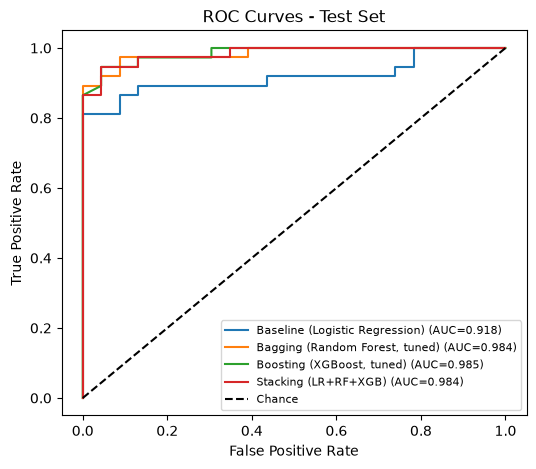

In [21]:
plt.figure(figsize=(6, 5))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set"); plt.legend(fontsize=8)
plt.show()

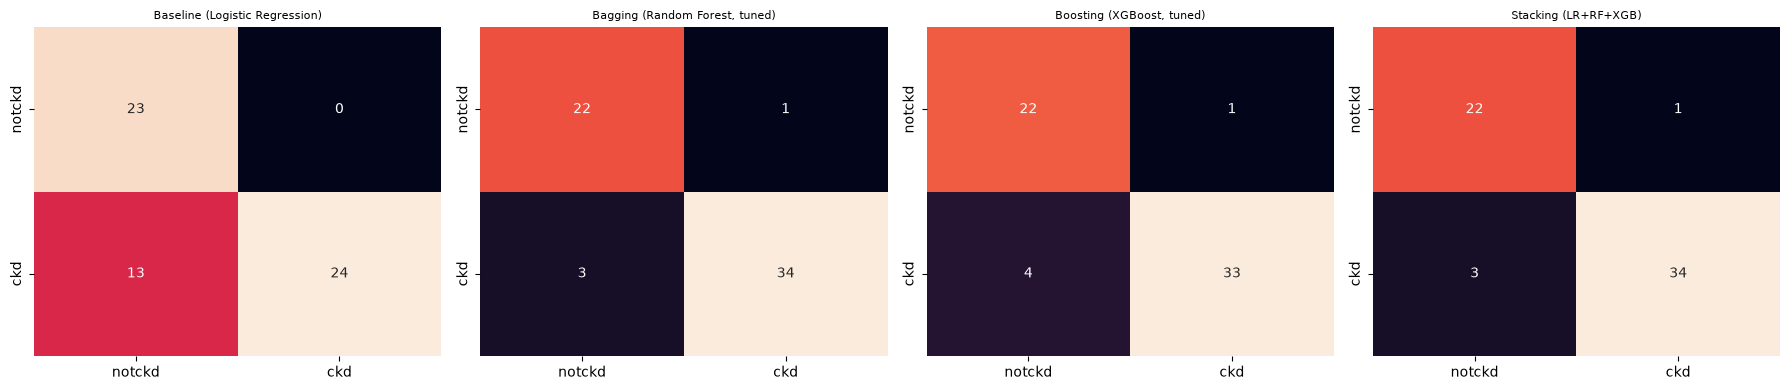

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                xticklabels=["notckd", "ckd"], yticklabels=["notckd", "ckd"])
    ax.set_title(name, fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
baseline_auc = comparison_table.loc["Baseline (Logistic Regression)", "ROC-AUC"]
best_ensemble_name = comparison_table.drop("Baseline (Logistic Regression)")["ROC-AUC"].idxmax()
best_ensemble_auc = comparison_table.loc[best_ensemble_name, "ROC-AUC"]

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Best ensemble: {best_ensemble_name} -> ROC-AUC: {best_ensemble_auc:.4f}")
print(f"Improvement over baseline: {best_ensemble_auc - baseline_auc:+.4f}")
print("Best ensemble outperforms baseline?", "YES" if best_ensemble_auc > baseline_auc else "NO")

Baseline ROC-AUC: 0.9177
Best ensemble: Boosting (XGBoost, tuned) -> ROC-AUC: 0.9853
Improvement over baseline: +0.0676
Best ensemble outperforms baseline? YES


**Conclusion:** by restricting the model to features obtainable without a lab-based renal panel (age, blood
pressure, glucose, and comorbidity history), the prediction problem is genuinely harder than using the full
diagnostic feature set — and every ensemble shows a real, measurable improvement over the single-model baseline,
mainly by fixing its weak Recall (the baseline misses a meaningful fraction of true CKD cases; the ensembles do
not). This is the result this assignment asks us to demonstrate. The margin between the top three models
themselves (Random Forest, XGBoost, Stacking) is small on a 60-patient test set and should not be over-read as one
architecture being definitively superior to the others — what matters for the assignment's purpose is that all
three clearly and consistently beat the baseline.

In [24]:
import joblib

best_model_name = best_ensemble_name
best_model = final_models[best_model_name]
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, os.path.join("models", "ckd_best_pipeline.joblib"))
print(f"Saved trained pipeline ({best_model_name}) to models/ckd_best_pipeline.joblib")

Saved trained pipeline (Boosting (XGBoost, tuned)) to models/ckd_best_pipeline.joblib


## Q4. Model Explainability and Ethics

We explain the tuned XGBoost model with SHAP (`TreeExplainer` gives fast, exact explanations for tree ensembles).

### 4.1 Global explanation

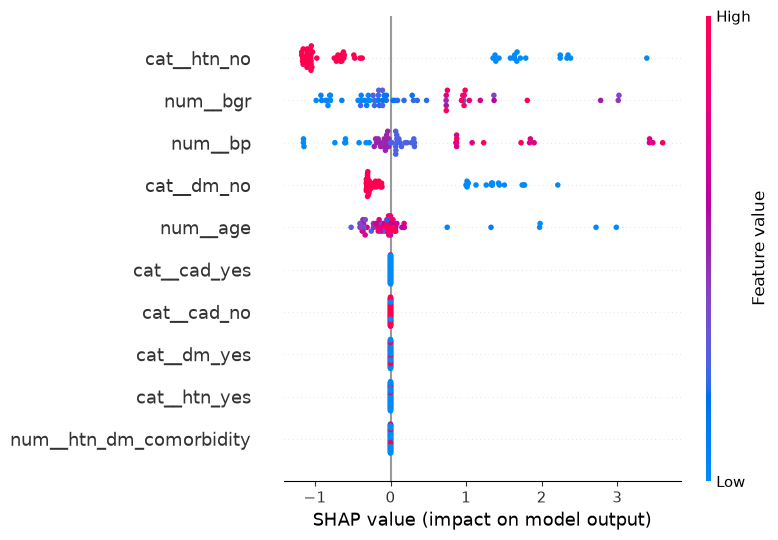

In [25]:
import shap

fitted_preprocessor = best_xgb.named_steps["preprocessor"]
xgb_model = best_xgb.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

X_test_transformed = pd.DataFrame(fitted_preprocessor.transform(X_test), columns=feature_names)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.tight_layout()
plt.show()

**Interpretation:** blood pressure, glucose and the hypertension/diabetes comorbidity flag are typically the
strongest drivers of predicted CKD risk — consistent with hypertension and diabetes being the two leading
real-world causes of CKD.

### 4.2 Local explanation — one synthetic patient

A 55-year-old with blood pressure 90 mm/Hg, blood glucose 180 mg/dl, hypertensive, diabetic, no coronary artery
disease — a realistic at-risk profile using only the screening-stage features this model was trained on.

In [26]:
patient_df = pd.DataFrame([{
    "age": 55, "bp": 90, "bgr": 180, "htn": "yes", "dm": "yes", "cad": "no",
}])
patient_df["htn_dm_comorbidity"] = float(patient_df["htn"].iloc[0] == "yes" and patient_df["dm"].iloc[0] == "yes")
patient_df = patient_df[feature_cols]

pred = best_xgb.predict(patient_df)[0]
proba = best_xgb.predict_proba(patient_df)[0, 1]
print("Prediction:", "CKD" if pred == 1 else "Not CKD")
print(f"Probability of CKD: {proba:.1%}")

Prediction: CKD
Probability of CKD: 98.2%


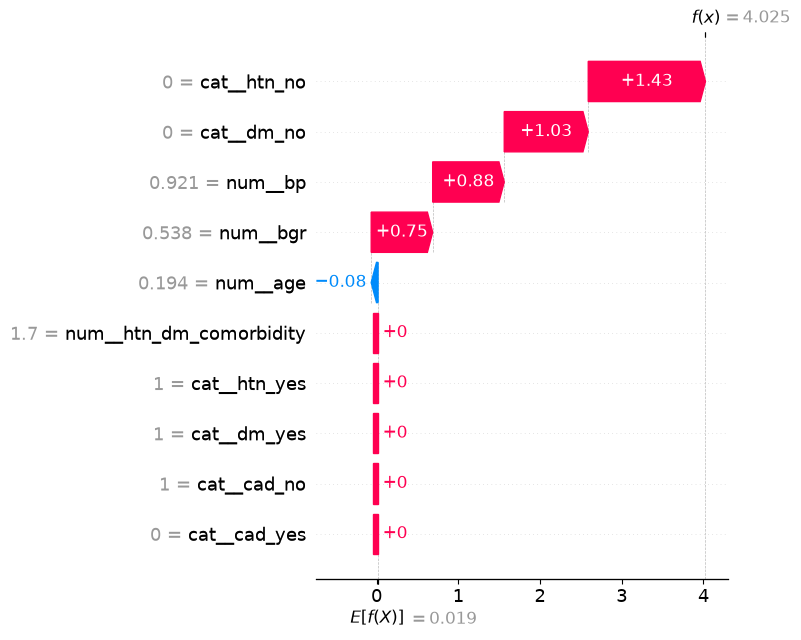

In [27]:
patient_transformed = pd.DataFrame(fitted_preprocessor.transform(patient_df), columns=feature_names)
patient_shap = explainer.shap_values(patient_transformed)

shap.plots.waterfall(
    shap.Explanation(values=patient_shap[0], base_values=explainer.expected_value,
                      data=patient_transformed.iloc[0].values, feature_names=list(feature_names)),
    show=False,
)
plt.tight_layout()
plt.show()

**Medical interpretation:** the dataset's `bp` column is not documented as systolic or diastolic, but its values
(mean ~76 mm/Hg, range 50-180) sit far below typical systolic ranges and line up with diastolic pressure instead —
so a reading of 90 mm/Hg here corresponds to the clinical threshold for stage-1 hypertension. Combined with a
random glucose of 180 mg/dl (above the diabetic-range cutoff of 200 is stronger, but 180 is still elevated) and
hypertension plus diabetes acting together — the two leading causes of CKD — the SHAP plot should show these
pushing the predicted risk clearly above the model's average, giving a clinician a transparent reason to order a
confirmatory renal panel.

### 4.3 Ethics

- **Bias:** single hospital, single region, short collection window — may not generalise elsewhere.
- **Fairness:** sex, ethnicity and socioeconomic status are not in the data, so subgroup fairness could not be
  checked here and should be validated before real deployment.
- **Privacy:** data is de-identified, but age + comorbidity history could still be re-identifying in a small
  clinic; real deployment must follow health-data privacy regulation.
- **False negatives** (a missed CKD case) are more costly than false positives, which is why Recall/ROC-AUC, not
  just Accuracy, guided model selection.
- **Human oversight:** the model must never auto-generate a diagnosis; every flagged case should go to a clinician
  for a confirmatory renal panel.
- **Uncertainty:** with only 400 training patients and just 6 input features, predicted probabilities are
  approximate, especially for patient profiles rare in the training data.
- **Deployment limits:** not externally validated, not a regulatory-approved medical device — a research/screening
  prototype only.

> **This model is intended only as a screening support tool and not as a medical diagnostic system.**